# Skip-Gram Neural Embedding (Word2Vec-style)

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import re
import collections
import random
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Download Shakespeare dataset
url = 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
response = requests.get(url)
text = response.text
print(text[:500])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return tokens

tokens = preprocess(text)
print(tokens[:20])

['first', 'citizen', 'before', 'we', 'proceed', 'any', 'further', 'hear', 'me', 'speak', 'all', 'speak', 'speak', 'first', 'citizen', 'you', 'are', 'all', 'resolved', 'rather']


In [ ]:
vocab_size = 5000
counter = collections.Counter(tokens)
most_common = counter.most_common(vocab_size-1)
vocab = {word: idx+1 for idx, (word, _) in enumerate(most_common)}
vocab['<UNK>'] = 0
inv_vocab = {idx: word for word, idx in vocab.items()}

def encode(word):
    return vocab.get(word, 0)

encoded_tokens = [encode(w) for w in tokens]

In [16]:
def to_skipgram(sent, window_size=2):
    pairs = []
    for i, center in enumerate(sent):
        for j in range(max(0, i-window_size), min(i+window_size+1, len(sent))):
            if i != j:
                pairs.append((center, sent[j]))
    return pairs

window_size = 2
sample_tokens = encoded_tokens[:100000]
pairs = to_skipgram(sample_tokens, window_size)
print('Total pairs:', len(pairs))
print('Example:', pairs[:5])
for center, context in pairs[:10]:
    print(f"{inv_vocab.get(center, '<UNK>')} -> {inv_vocab.get(context, '<UNK>')}")

Total pairs: 399994
Example: [(88, 267), (88, 137), (267, 88), (267, 137), (267, 35)]
first -> citizen
first -> before
citizen -> first
citizen -> before
citizen -> we
before -> first
before -> citizen
before -> we
before -> proceed
we -> citizen


In [17]:
X = torch.tensor([p[0] for p in pairs], dtype=torch.long)
Y = torch.tensor([p[1] for p in pairs], dtype=torch.long)

In [18]:
class SkipGramDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

batch_size = 256
dataset = SkipGramDataset(X, Y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [19]:
embedding_dim = 50
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)
    def forward(self, center_words):
        embeds = self.embeddings(center_words)
        out = self.linear(embeds)
        return out

model = SkipGramModel(vocab_size, embedding_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 5

losses1 = []
for epoch in range(epochs):
    total_loss = 0
    for centers, contexts in dataloader:
        centers = centers.to(device)
        contexts = contexts.to(device)
        optimizer.zero_grad()
        outputs = model(centers)
        loss = loss_fn(outputs, contexts)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    losses1.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 5.9270
Epoch 2, Loss: 5.8306
Epoch 3, Loss: 5.8015
Epoch 4, Loss: 5.7852
Epoch 5, Loss: 5.7743


## Visualize Embeddings with PCA

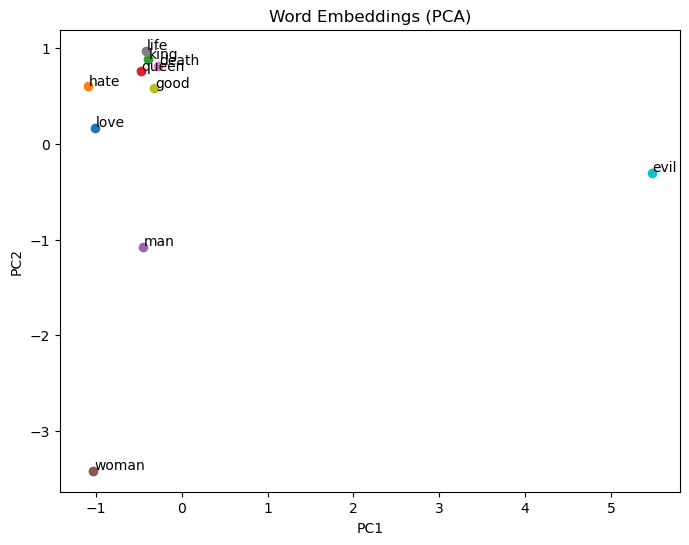

In [24]:
# Get embeddings for some words
words = ['love', 'hate', 'king', 'queen', 'man', 'woman', 'death', 'life', 'good', 'evil']
word_ids = [vocab.get(w, 0) for w in words]
embeds = model.embeddings(torch.tensor(word_ids).to(device)).detach().cpu().numpy()

# PCA to 2D
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(embeds)

# Plot
plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    x, y = embeds_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)
plt.title('Word Embeddings (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Try a different embedding size and compare accuracy and PCA visualization


[Embedding 100] Epoch 1, Loss: 6.5469
[Embedding 100] Epoch 2, Loss: 6.1335
[Embedding 100] Epoch 3, Loss: 5.9896
[Embedding 100] Epoch 4, Loss: 5.9056
[Embedding 100] Epoch 5, Loss: 5.8535


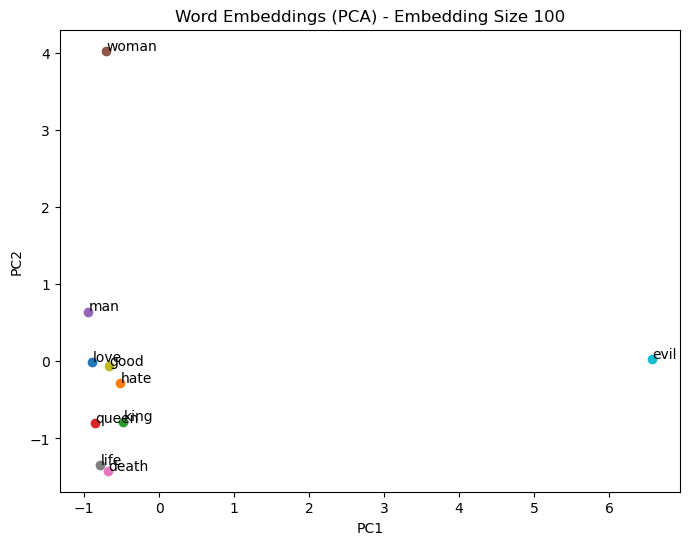

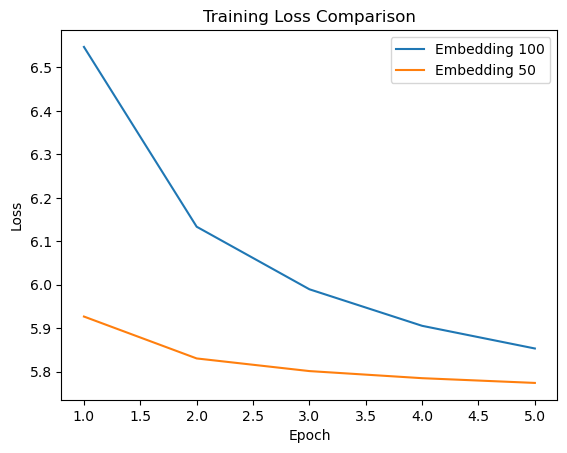

In [25]:
embedding_dim2 = 100
model2 = SkipGramModel(vocab_size, embedding_dim2).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.01)
loss_fn2 = nn.CrossEntropyLoss()

losses2 = []
for epoch in range(epochs):
    total_loss = 0
    for centers, contexts in dataloader:
        centers = centers.to(device)
        contexts = contexts.to(device)
        optimizer2.zero_grad()
        outputs = model2(centers)
        loss = loss_fn2(outputs, contexts)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    losses2.append(avg_loss)
    print(f"[Embedding 100] Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Compare PCA visualization
words = ['love', 'hate', 'king', 'queen', 'man', 'woman', 'death', 'life', 'good', 'evil']
word_ids = [vocab.get(w, 0) for w in words]
embeds2 = model2.embeddings(torch.tensor(word_ids).to(device)).detach().cpu().numpy()

pca2 = PCA(n_components=2)
embeds_2d_2 = pca2.fit_transform(embeds2)

plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    x, y = embeds_2d_2[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)
plt.title('Word Embeddings (PCA) - Embedding Size 100')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Compare losses with embedding_dim=50
plt.plot(range(1, epochs+1), losses2, label='Embedding 100')
plt.plot(range(1, epochs+1), losses1, label='Embedding 50')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

Looks like Adding more dimensions without adding more training data just introduced more noise into the process.